# **Lab 2: PCA in Python**

dataset: `Universities.csv`

In this lab we take a 17-variable dataset about US universities and compress it
down to a handful of **principal components** - new variables that summarise most
of the information in far fewer dimensions.

We let `sklearn` and `pandas` do all of the arithmetic: there is no hand-computed
math anywhere in this notebook.

In [ ]:
# Load the libraries this lab uses, and draw plots inside the notebook.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px                          # interactive plots (pre-installed on Colab)
from sklearn.preprocessing import StandardScaler     # does the scaling for us
from sklearn.decomposition import PCA                # does the PCA for us


## **Task 1:** Data cleaning (without scaling yet)

Objective: PCA only works on metric variables. So we need to remove non-metric variables and also any empty entries

In [34]:
# load the data and review
uni_df = pd.read_csv('https://raw.githubusercontent.com/AnalyticsArmory/data/main/Universities.csv')
uni_df.head()

,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193.0,146.0,55.0,16.0,44.0,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.0
1,University of Alaska at Fairbanks,AK,1,1852.0,1427.0,928.0,NaN,NaN,3885.0,4519.0,1742.0,5226.0,1800.0,1790.0,155.0,650.0,2304.0,67.0,10.0,NaN
2,University of Alaska Southeast,AK,1,146.0,117.0,89.0,4.0,24.0,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.0
3,University of Alaska at Anchorage,AK,1,2065.0,1598.0,1162.0,NaN,NaN,6209.0,10537.0,1742.0,5226.0,2600.0,2520.0,114.0,580.0,1260.0,48.0,13.7,NaN
4,Alabama Agri. & Mech. Univ.,AL,1,2817.0,1920.0,984.0,NaN,NaN,3958.0,305.0,1700.0,3400.0,1108.0,1442.0,155.0,500.0,850.0,53.0,14.3,40.0


In [35]:
# shape of dataframe
uni_df.shape

(1302, 20)

In [36]:
# concise summary containing variable types
uni_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   College Name              1302 non-null   object 
 1   State                     1302 non-null   object 
 2   Public (1)/ Private (2)   1302 non-null   int64  
 3   # appli. rec'd            1292 non-null   float64
 4   # appl. accepted          1291 non-null   float64
 5   # new stud. enrolled      1297 non-null   float64
 6   % new stud. from top 10%  1067 non-null   float64
 7   % new stud. from top 25%  1100 non-null   float64
 8   # FT undergrad            1299 non-null   float64
 9   # PT undergrad            1270 non-null   float64
 10  in-state tuition          1272 non-null   float64
 11  out-of-state tuition      1282 non-null   float64
 12  room                      981 non-null    float64
 13  board                     804 non-null    float64
 14  add. fee

In [37]:
# how many distinct values does each column take?
# a column with only a handful of distinct values is a label in disguise, not a measurement
uni_df.nunique()

,0
College Name,1274
State,51
Public (1)/ Private (2),2
# appli. rec'd,1127
# appl. accepted,1065
# new stud. enrolled,870
% new stud. from top 10%,90
% new stud. from top 25%,93
# FT undergrad,1151
# PT undergrad,883


Notice two problems. `College Name`, `State` and `Public (1)/ Private (2)` are labels
rather than measurements, so PCA cannot use them. And several columns have **blank**
entries where a university did not report the figure — `board` is missing for 498 of
the 1,302 universities and `room` for 321. We fix both below.


In [38]:
# first drop the missing values, on the FULL table
# doing it here (rather than after dropping the labels) keeps 'College Name' lined up
# with the rows we keep, so we can label our plots later on
# option "any" drops any line that has even a single missing value.
# an alternative option is "all" which drops the row only if
# all columns of that row have 0 entries
uni_clean = uni_df.dropna(how='any')
# it's good practice to also reset the index after dropping empty rows...
# the option drop=True removes useless information that reset_index adds
uni_clean = uni_clean.reset_index(drop=True)
uni_clean.shape

(471, 20)

In [39]:
# now create a list of the non-metric columns to be dropped
cols = ['College Name','State','Public (1)/ Private (2)']
# then use the dataframe drop() command to drop them
uni_mdf = uni_clean.drop(cols, axis=1)
uni_mdf.head()

,# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,193.0,146.0,55.0,16.0,44.0,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.0
1,146.0,117.0,89.0,4.0,24.0,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.0
2,805.0,588.0,287.0,67.0,88.0,1376.0,207.0,11660.0,11660.0,2050.0,2430.0,120.0,400.0,900.0,74.0,14.0,72.0
3,608.0,520.0,127.0,26.0,47.0,538.0,126.0,8080.0,8080.0,1380.0,2540.0,100.0,500.0,1100.0,63.0,11.4,44.0
4,4414.0,1500.0,335.0,30.0,60.0,908.0,119.0,5666.0,5666.0,1424.0,1540.0,418.0,1000.0,1400.0,56.0,15.5,46.0


In [40]:
#check the resulting shape
print(uni_mdf.shape)

(471, 17)


**Question 1.** The file arrived with 1,302 universities and the cleaned table has 471.
Where did the other 831 go, and what would you want to check before you are comfortable
with that?


**Answer**

*Provide your answer here*


## **Task 2:** Let's now try to check whether there are any correlations between the columns

In [41]:
# correlation table for the quantitative variables
# the corr() function creates a new dataframe containing the correlation matrix
corr_mat = uni_mdf.corr()
corr_mat

,# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
# appli. rec'd,1.000000,0.935770,0.819857,0.298749,0.325391,0.795643,0.412259,-0.118912,0.075774,0.232367,0.125895,0.299770,0.105389,0.178013,0.377163,0.077846,0.182058
# appl. accepted,0.935770,1.000000,0.895155,0.136035,0.201216,0.864748,0.470371,-0.202329,-0.005668,0.170734,0.053769,0.292556,0.071003,0.205665,0.343457,0.164037,0.098350
# new stud. enrolled,0.819857,0.895155,1.000000,0.138461,0.179462,0.968643,0.558167,-0.335632,-0.139695,0.019735,-0.034223,0.283604,0.061411,0.295832,0.320065,0.225909,0.012737
% new stud. from top 10%,0.298749,0.136035,0.138461,1.000000,0.906129,0.102562,-0.126367,0.553145,0.625991,0.343577,0.375795,0.026392,0.116046,-0.130457,0.545600,-0.460256,0.558186
% new stud. from top 25%,0.325391,0.201216,0.179462,0.906129,1.000000,0.155569,-0.097473,0.499012,0.576582,0.324089,0.359908,0.015944,0.124989,-0.123673,0.563439,-0.370763,0.575379
# FT undergrad,0.795643,0.864748,0.968643,0.102562,0.155569,1.000000,0.592776,-0.386847,-0.184727,0.008577,-0.055043,0.249330,0.070380,0.337147,0.313091,0.256107,-0.042209
# PT undergrad,0.412259,0.470371,0.558167,-0.126367,-0.097473,0.592776,1.000000,-0.341228,-0.220836,-0.025101,-0.015629,0.089498,0.080401,0.291897,0.138053,0.194537,-0.235267
in-state tuition,-0.118912,-0.202329,-0.335632,0.553145,0.499012,-0.386847,-0.341228,1.000000,0.937382,0.490391,0.582410,-0.219205,0.055218,-0.349198,0.288653,-0.604224,0.579677
out-of-state tuition,0.075774,-0.005668,-0.139695,0.625991,0.576582,-0.184727,-0.220836,0.937382,1.000000,0.557741,0.606638,-0.097724,0.067404,-0.320028,0.458300,-0.596022,0.621332
room,0.232367,0.170734,0.019735,0.343577,0.324089,0.008577,-0.025101,0.490391,0.557741,1.000000,0.482551,0.091968,0.192907,-0.177831,0.321535,-0.345376,0.369564


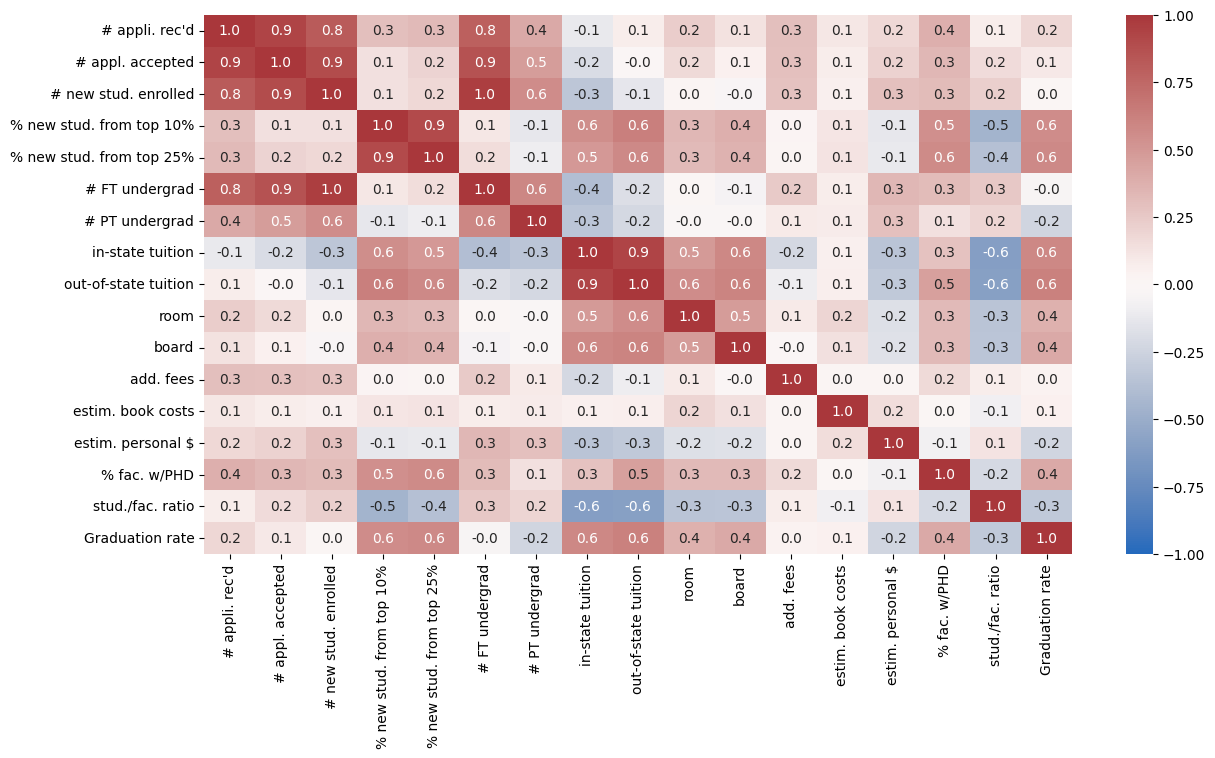

In [42]:
# easier to interpret using a heatmap with colormap, from the seaborn package
# 'vlag' is a diverging colormap: blue = negative, white = zero, red = positive
# list of available color maps: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.figure(figsize=(14,7))
sns.heatmap(corr_mat, annot=True, fmt=".1f", vmin=-1, vmax=1, cmap='vlag');

cluster in top left catches eye first. lots of correlation between aps received, accepted and # students enrolled which makes sense. all dependent on eachother. #Ft undergrads also high corr with applications accepted and recieved.

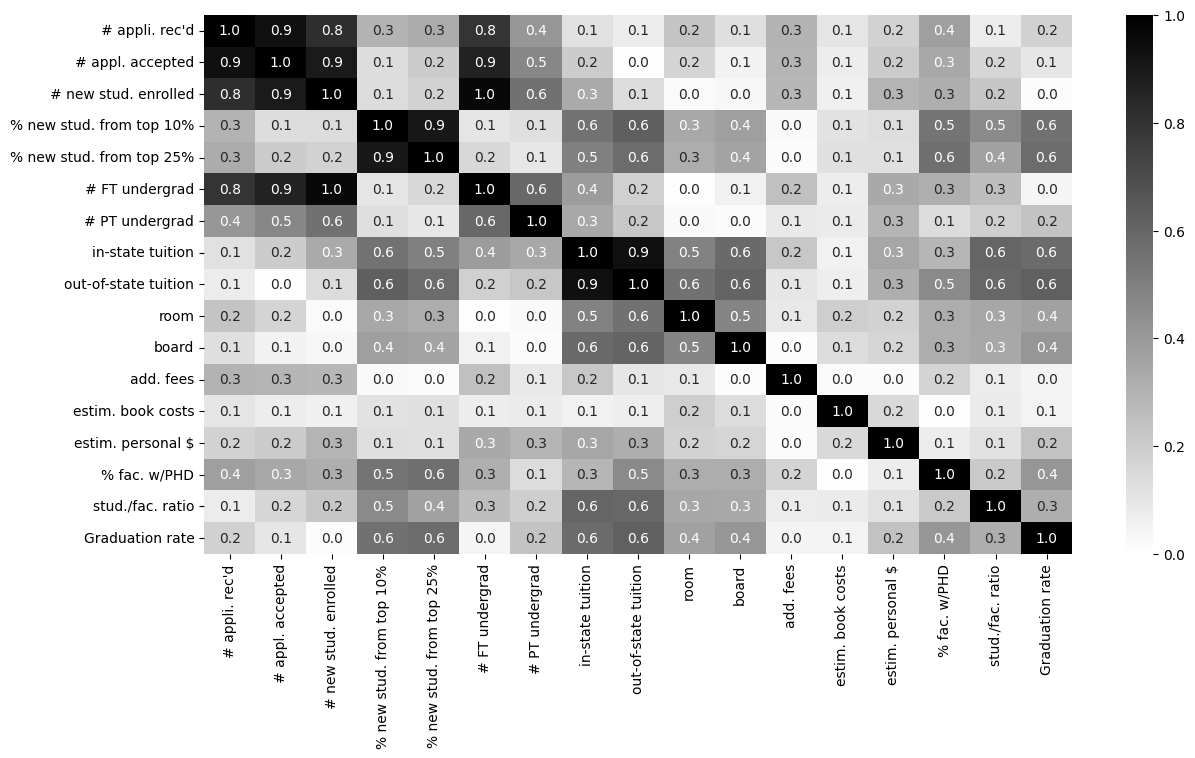

In [43]:
# if we only care about the magnitude of corr, not the sign
# it's best to use grayscale
plt.figure(figsize=(14,7))
sns.heatmap(np.absolute(corr_mat), annot=True, fmt=".1f", vmin=0, vmax=1, cmap="gray_r");

## **Task 3:** Scale the data and run PCA

One step comes before the PCA. Look at what our 17 variables actually contain — not their
meaning, just the size of the numbers in each column.

In [44]:
# min, max, mean and standard deviation for every variable, worst offenders first
# agg() builds the whole table in one line; .T turns it on its side so it reads like a list
spread = uni_mdf.agg(['min', 'max', 'mean', 'std']).T.sort_values('std', ascending=False)
print('most variable column is', round(spread['std'].max() / spread['std'].min()),
      'times more spread out than the least')
spread.round(1)

most variable column is 1415 times more spread out than the least


,min,max,mean,std
in-state tuition,608.0,20100.0,9406.6,5516.8
# FT undergrad,249.0,31643.0,3562.9,4669.2
out-of-state tuition,1044.0,20100.0,10575.2,4311.7
# appli. rec'd,77.0,48094.0,3147.3,4073.1
# appl. accepted,61.0,26330.0,2063.0,2503.8
# PT undergrad,1.0,21836.0,797.5,1545.8
# new stud. enrolled,27.0,6392.0,780.7,915.6
room,640.0,4816.0,2221.1,713.2
estim. personal $,250.0,6800.0,1311.9,681.8
board,531.0,4541.0,2121.9,566.9


The standard deviations run from **3.9** for `stud./fac. ratio` up to **5,517** for
`in-state tuition` — a factor of about **1,400**. That gap is not a statement about which
variables matter. It is a statement about the units they happen to be quoted in: dollars,
head-counts, ratios and percentages, all in the same table.

This is a problem, because PCA hunts for directions of maximum **variance**, and it cannot tell a
genuinely important variable from one that merely has big numbers. Left as-is, tuition and the
head-count columns would decide the first components on the strength of their units alone, and
`stud./fac. ratio` would be invisible.

**Standardizing** fixes it: subtract each column's mean and divide by its standard deviation, so
every variable arrives at the PCA with mean 0 and standard deviation 1 — one variable, one vote.

In [ ]:
# Standardization (0 mean, unit variance) is done by sklearn's StandardScaler
# fit_transform() learns the mean/stdev AND applies them in one step
# wrapping the result in a DataFrame with columns=... keeps our variable names,
# which saves us from relabelling everything by hand later on
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(uni_mdf), columns=uni_mdf.columns)
scaled_df.head()

Now, let's check that the scaler worked as intended, that is, it created columns with zero mean and unit variance

In [ ]:
# agg() runs both summaries at once
scaled_df.agg(['mean', 'std']).round(3)

PCA stores its results in three attributes, and `pandas` will lay them out for us:

- `explained_variance_` -> the eigenvalues, $\lambda$
- `explained_variance_ratio_` -> the share of total variance each component carries
- `components_` -> the weights

In [ ]:
# PCA after scaling
# fit_transform() runs the PCA AND hands back the component scores in one step,
# so we never have to call fit() and transform() separately
pcs = PCA(n_components=12)
scores = pcs.fit_transform(scaled_df)

# name the components PC1...PC12 once, and reuse the names everywhere below
pc_names = ['PC' + str(i+1) for i in range(pcs.n_components_)]
scores_df = pd.DataFrame(scores, columns=pc_names)

# eigenvalues (lambda) come straight from explained_variance_
eig = pcs.explained_variance_

# view the importance of the principal components
summary_df = pd.DataFrame({
    'Eigenvalue': eig,
    '% of variance': pcs.explained_variance_ratio_ * 100,
    'Cumulative %': np.cumsum(pcs.explained_variance_ratio_) * 100
}, index=pc_names)
summary_df.round(3)

**Question 2.** Read the `Cumulative %` column of the table above. How much of the
variation in the 17 original variables do the first four components carry between them,
and how much does the first one carry on its own?


**Answer**

*Provide your answer here*


### From **weights** to the **component matrix**

`components_` gives us the *weights* - the recipe that mixes the original variables
into each component. That is not the same thing as the **component matrix** on the
slides, whose entries are the **correlations** between each original variable and
each component.

The two are one short step apart. Component $j$ has variance $\lambda_j$ (its
eigenvalue), so rescaling the weight by $\sqrt{\lambda_j}$ turns it into a correlation:

$$corr_{ij} = weight_{ij} \times \sqrt{\lambda_j}$$

In [ ]:
# careful: the components_ attribute puts the components on the ROWS and the
# original variables on the COLUMNS. This is the opposite of the format we have in
# our slides, so we transpose with .T and hand pandas the variable names directly --
# no need to rebuild the labels by hand.
weights_df = pd.DataFrame(pcs.components_.T, index=uni_mdf.columns, columns=pc_names)
weights_df.round(3)

In [ ]:
# glue the component scores next to the scaled variables, ask pandas for corr(),
# then read off the block that pairs the variables with the components
loadings_df = pd.concat([scores_df, scaled_df], axis=1).corr().loc[uni_mdf.columns, pc_names]
loadings_df.round(2)

In [ ]:
# the component matrix is much easier to read as a heatmap than as a wall of numbers
plt.figure(figsize=(13,7))
sns.heatmap(loadings_df, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap='vlag')
plt.title('Component matrix: correlation of each variable with each component');

In [ ]:
# one component at a time, as a bar chart -- the clearest way to read a component
loadings_df[['PC1','PC2']].plot.barh(figsize=(9,8), width=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('correlation with the component')
plt.title('What do PC1 and PC2 actually measure?');

**Question 3.** Using the bar chart and the component matrix above it, say in plain
business language what each of the first four components is measuring.


**Answer**

*Provide your answer here*


## **Task 4:** Let's now try to figure out how many components we need...

In [ ]:
#Eigenvalues are given by the PCA explained_variance_ attribute
print(summary_df['Eigenvalue'].round(2).to_string())

In [ ]:
# scree plot of eigenvalues
# because summary_df is already indexed PC1...PC12, .plot() labels the axis for us
ax = summary_df['Eigenvalue'].plot(marker='o', color='red', figsize=(10,5))
ax.axhline(y=1, color='b', linestyle='--')      # the latent root (Kaiser) cut-off
ax.set_title('Scree Plot')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Eigenvalue');

In [ ]:
# the same story told as variance explained: bars per component, line for the running total
ax = summary_df['% of variance'].plot.bar(figsize=(10,5), color='0.4')
summary_df['Cumulative %'].plot(marker='o', color='red', ax=ax)
ax.set_ylabel('% of variance')
ax.legend(['Cumulative %', '% of variance']);

**Question 4.** The scree plot has a dashed blue line at an eigenvalue of 1. Count the
points above it. How many components does the latent root (Kaiser) criterion say to keep,
and what has the dataset become once you keep only those?


**Answer**

*Provide your answer here*


## **Bonus task 1:** Keep the first 4 components and merge them into a dataframe, to then run other models, like linear regression, etc.

For this, we're going to need to extract the actual PCA values for each component (also called component scores). These values represent the linear combinations of the original data values.

In [ ]:
# Keeping the first 4 components based on the latent root criterion
# fit() function runs the PCA and shows the % of var explained
# fit_transform() function runs the PCA and hands back the actual PCA values (the component scores)
pcs4 = PCA(n_components=4)
principalComponents = pcs4.fit_transform(scaled_df)

# make the output more readable by creating a new dataframe
principalDF = pd.DataFrame(principalComponents.round(3), columns=['F1','F2','F3','F4'])
principalDF

In [ ]:
# confirm component scores are orthogonal (correlations of 0 off the diagonal)
principalDF.corr().round(4)

In [ ]:
# merge component scores with the cleaned dataframe (after missing values were dropped)
# we will use the concatenate, concat() function
# because we dropped the missing rows BEFORE splitting off the labels, the rows still line up
uni_df_aug = pd.concat([uni_clean, principalDF], axis=1)
uni_df_aug.head()

## **Bonus task 2:** use the components as inputs to a regression

A component score is just a number for each university, so it can feed any model that takes
numbers. Here we predict a university's **% of faculty with PhDs** from its component scores
instead of from the original 16 variables.

One thing has to change first. `% fac. w/PHD` is the variable we are trying to predict, so it
must come **out** of the PCA — otherwise the target is baked into its own predictors and the
regression is grading its own homework. That means re-standardising and re-running the PCA on
the remaining 16 variables.

In [ ]:
# the target: what we want to predict
y = uni_clean['% fac. w/PHD']

# the predictors: everything metric EXCEPT the target
X_reg = uni_clean.drop(cols + ['% fac. w/PHD'], axis=1)

# scale, then run PCA -- same two steps as Task 4, but on 16 variables instead of 17,
# so these are NEW objects and NOT the scaler/pcs we fitted earlier
scaler_reg = StandardScaler()
X_reg_scaled = pd.DataFrame(scaler_reg.fit_transform(X_reg), columns=X_reg.columns)

pcs_reg = PCA(n_components=4)
F_reg = pd.DataFrame(pcs_reg.fit_transform(X_reg_scaled), columns=['F1','F2','F3','F4'])

print('predictors:', X_reg.shape)
print(f'variance kept by the 4 components: {pcs_reg.explained_variance_ratio_.sum()*100:.1f}%')
F_reg.head()

In [ ]:
# statsmodels gives us the familiar regression table
import statsmodels.api as sm

# add_constant() puts the intercept column in for us
model = sm.OLS(y, sm.add_constant(F_reg)).fit()
print(model.summary())

**Question 5.** The regression table reports an R-squared of 0.417. What does that
number say about the trade we made by replacing 16 variables with 4 components?


**Answer**

*Provide your answer here*


### Now let's use the model on a university we know

Boston University is in the cleaned data. Let's see what the model says about it.

In [ ]:
# pull out the BU row (it survived the dropna, at index 136)
BU_data = uni_clean.loc[uni_clean['College Name'].str.contains('Boston University', case=False)]
BU_data[['College Name', 'State', '% fac. w/PHD']]

In [ ]:
# BU's real value is 80% -- now let's see what the model predicts.
# The new row has to travel through the SAME two steps, in the same order:
# transform() applies the scaling and the rotation we already learned.
# NOTE: transform(), never fit_transform() -- fitting again would re-learn both
# from this single row and give us nonsense.
BU_X = BU_data.drop(cols + ['% fac. w/PHD'], axis=1)
BU_scaled = pd.DataFrame(scaler_reg.transform(BU_X), columns=X_reg.columns)
BU_F = pd.DataFrame(pcs_reg.transform(BU_scaled), columns=['F1','F2','F3','F4'])
print(BU_F.round(3))

# has_constant='add' forces the intercept column in; with a single row statsmodels
# cannot tell an intercept from an ordinary constant column, so we say so explicitly
prediction = model.predict(sm.add_constant(BU_F, has_constant='add'))
print(f"\npredicted % fac. w/PHD: {prediction.iloc[0]:.1f}")
actual = BU_data["% fac. w/PHD"].iloc[0]
print(f"actual    % fac. w/PHD: {actual:.1f}")

**Question 6.** The model predicts that 108% of BU's faculty hold PhDs; the real figure
is 80%, and a percentage above 100 is impossible. What went wrong — and is PCA the thing
to blame?


**Answer**

*Provide your answer here*


## **Bonus task 3:** picturing 471 universities on 2 axes

We have gone from 17 columns to 4. That is few enough to actually *draw*, which is the other
reason people reach for PCA. Below: the universities on their first two components, and then the
same universities placed by a **non-linear** method for comparison.

In [ ]:
# 471 universities, 17 variables, plotted on 2 axes
# plotly gives us the hover labels for free -- point at a dot to see which school it is
uni_df_aug['Type'] = uni_df_aug['Public (1)/ Private (2)'].map({1: 'Public', 2: 'Private'})

px.scatter(uni_df_aug, x='F1', y='F2', color='Type', hover_name='College Name',
           labels={'F1': 'F1 - quality & expense', 'F2': 'F2 - size & popularity'},
           title='US universities on their first two principal components')

**Question 7.** Hover over the points at the far right of `F1` and at the top of
`F2`. Do the universities you find there match the story the component matrix told about
those two components?


**Answer**

*Provide your answer here*


### A non-linear alternative: t-SNE

Every principal component is a *straight-line* combination of the original columns, which is why we could read F1 and F2 off the component matrix. t-SNE is **non-linear**: it ignores the columns entirely and only tries to keep universities that were close together in 17 dimensions close together in 2.

**Read the plot below with care.** Its axes have no units and no component matrix behind them, so nothing tells you what "dimension 1" means. Distances between the groups, and how spread out each group looks, are *not* meaningful. The picture also changes if you change `perplexity` or `random_state`. Use t-SNE to spot groups, never to measure them.

In [ ]:
# t-SNE: the non-linear alternative, run on the same scaled data as the PCA above
from sklearn.manifold import TSNE

# perplexity is roughly "how many neighbours count as local"; random_state fixes the seed
# so that this plot comes out the same every time we run the cell
uni_df_aug[['t1', 't2']] = TSNE(n_components=2, perplexity=30,
                                random_state=0).fit_transform(scaled_df)

px.scatter(uni_df_aug, x='t1', y='t2', color='Type', hover_name='College Name',
           labels={'t1': 'dimension 1 (no units)', 't2': 'dimension 2 (no units)'},
           title='The same 471 universities, embedded by t-SNE')

---
# **Follow up Questions and Exercises**

Work through these once you have run everything above. Write your answers in the cells
provided.


**Exercise 1.** Re-run the PCA of Task 3 with `PCA(n_components=17)` instead of 12.
Do the first four eigenvalues change? Explain why or why not.


In [ ]:
# Your code here


**Answer**

*Provide your answer here*


**Exercise 2.** Set `n_components=2` and rebuild the component matrix. Are the
correlations for PC1 and PC2 the same ones you got with 12 components?


In [ ]:
# Your code here


**Answer**

*Provide your answer here*


**Question 8.** `weights_df` and `loadings_df` hold the same information in two
different scalings. Which one would you put in front of an executive, and why?


**Answer**

*Provide your answer here*


**Question 9.** A component's correlations can be large and negative — look at
`stud./fac. ratio` on PC1. Does a negative correlation make that variable less important
to the component?


**Answer**

*Provide your answer here*


**Question 10.** The t-SNE plot appears to separate public from private schools at
least as cleanly as the PCA plot does. Is the PCA plot still the one you would put in
front of a client?


**Answer**

*Provide your answer here*


**Question 11.** The regression predicted 108% of faculty with PhDs for BU. Name one
change to **the model** — not to the data — that would make a prediction above 100%
impossible.


**Answer**

*Provide your answer here*
